In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")


In [4]:
df=pd.read_csv("AIML Dataset.csv")


In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436601 entries, 0 to 436600
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            436601 non-null  int64  
 1   type            436601 non-null  object 
 2   amount          436601 non-null  float64
 3   nameOrig        436601 non-null  object 
 4   oldbalanceOrg   436601 non-null  float64
 5   newbalanceOrig  436601 non-null  float64
 6   nameDest        436600 non-null  object 
 7   oldbalanceDest  436600 non-null  float64
 8   newbalanceDest  436600 non-null  float64
 9   isFraud         436600 non-null  float64
 10  isFlaggedFraud  436600 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 36.6+ MB


In [7]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [8]:
df["isFraud"].value_counts()

,count
isFraud,
0.0,436382
1.0,218


In [9]:
df["isFlaggedFraud"].value_counts()

,count
isFlaggedFraud,
0.0,436600


In [10]:
df.isnull()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
436596,False,False,False,False,False,False,False,False,False,False,False
436597,False,False,False,False,False,False,False,False,False,False,False
436598,False,False,False,False,False,False,False,False,False,False,False
436599,False,False,False,False,False,False,False,False,False,False,False


In [11]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [12]:
df.shape

(436601, 11)

In [13]:
round((df["isFraud"].value_counts()[1]/df.shape[0])*100,2)

np.float64(0.05)

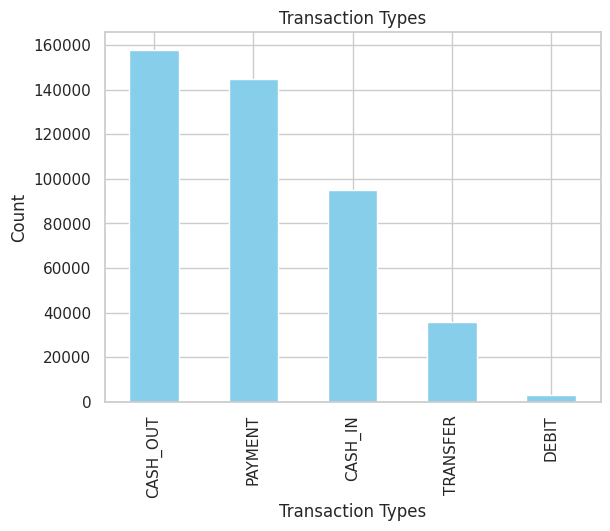

In [14]:
df["type"].value_counts().plot(kind="bar",title="Transaction Types",color="skyblue")
plt.xlabel("Transaction Types")
plt.ylabel("Count")
plt.    show()

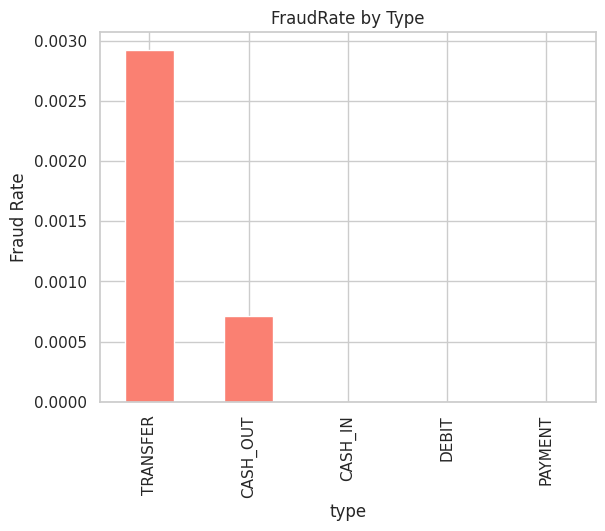

In [15]:
fraud_by_type=df.groupby("type")['isFraud'].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar",title="FraudRate by Type",color="salmon")
plt.ylabel("Fraud Rate")
plt.show()

In [16]:
df["amount"].describe().astype(int)

,amount
count,436601
mean,170559
std,280524
min,0
25%,13508
50%,81950
75%,227637
max,10000000


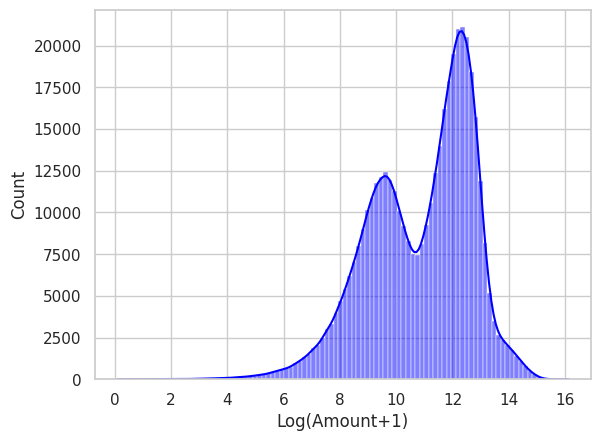

In [17]:
sns.histplot(np.log1p(df["amount"]),bins=100,kde=True,color="blue")
plt.xlabel("Log(Amount+1)")
plt.show()

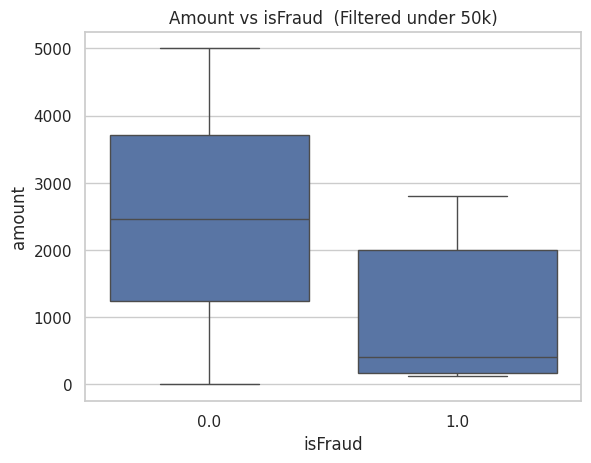

In [18]:
sns.boxplot(data=df[df["amount"]<5000],x="isFraud",y="amount")
plt.title("Amount vs isFraud  (Filtered under 50k)")
plt.show()

In [19]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [20]:
df["balanceDiffOrig"]=df["oldbalanceOrg"]-df["newbalanceOrig"]
df["balanceDiffDest"]=df["newbalanceDest"]-df["oldbalanceDest"]

In [21]:
(df["balanceDiffOrig"]<0).sum()

np.int64(94769)

In [22]:
(df["balanceDiffDest"]<0).sum()

np.int64(85736)

In [23]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0


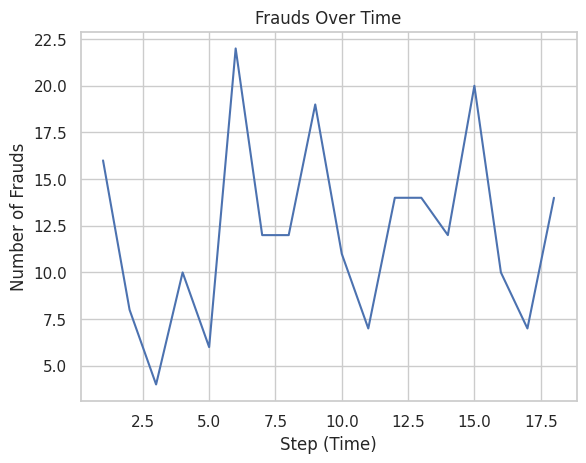

In [24]:
frauds_per_step=df[df["isFraud"] == 1]["step"].value_counts().sort_index()
plt.plot(frauds_per_step.index,frauds_per_step.values,label="Frauds per Step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

In [25]:
df.drop(columns="step",inplace=True)